# Fashion MNIST Image Classifier using CNN
A convolutional neural network (CNN) to classify clothing items from the FashionMNIST dataset

![clothing_classification](clothing_classification.png)


Fashion Forward is a new AI-based e-commerce clothing retailer.
They want to use image classification to automatically categorize new product listings, making it easier for customers to find what they're looking for. It will also assist in inventory management by quickly sorting items.

As a data scientist tasked with implementing a garment classifier, my primary objective is to develop a machine learning model capable of accurately categorizing images of clothing items into distinct garment types such as shirts, trousers, shoes, etc.

As the lead data scientist on this project, I developed a convolutional neural network (CNN) to automate product tagging for Fashion Forward’s e-commerce platform. My goal was to streamline the categorization of new clothing items, making it easier for customers to find products and improving inventory management.

I trained the model on the FashionMNIST dataset, keeping the number of epochs low to ensure efficient development and testing. After training, I generated predictions on the test set and calculated key performance metrics, including overall accuracy, as well as per-class precision and recall. These metrics help us understand the model’s strengths and areas for improvement, ensuring our product tagging is both accurate and reliable.

This solution will enable Fashion Forward to scale its product catalog more efficiently and deliver a better shopping experience for our customers.

# 1. Imports & Setup


In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchmetrics import Accuracy, Precision, Recall
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [22]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')


Using device: cpu


# 2. Data Loading & Preparation



In [23]:
# Transform and load datasets
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

class_labels = train_data.classes
image_size = train_data[0][0].shape[1]


In [24]:
# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


# 3. Model Definition

In [25]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * (image_size // 2) ** 2, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x


# 4. Model Training

In [26]:
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.4899
Epoch [2/5], Loss: 0.3393
Epoch [3/5], Loss: 0.3033
Epoch [4/5], Loss: 0.2825
Epoch [5/5], Loss: 0.2682


# 5. Evaluation

In [27]:
accuracy_metric = Accuracy(task='multiclass', num_classes=10)
precision_metric = Precision(task='multiclass', num_classes=10, average=None)
recall_metric = Recall(task='multiclass', num_classes=10, average=None)

model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

        accuracy_metric(preds, labels)
        precision_metric(preds, labels)
        recall_metric(preds, labels)


# 6. Metrics

In [28]:
accuracy = accuracy_metric.compute().item()
precision = precision_metric.compute().tolist()
recall = recall_metric.compute().tolist()

print(f"✅ Accuracy: {accuracy * 100:.2f}%")
print(f"🎯 Precision (per class): {precision}")
print(f"🔁 Recall (per class): {recall}")


✅ Accuracy: 89.48%
🎯 Precision (per class): [0.8325266242027283, 0.9918032884597778, 0.8476684093475342, 0.8661710023880005, 0.8147087097167969, 0.9701195359230042, 0.7324561476707458, 0.9481037855148315, 0.9817258715629578, 0.9580000042915344]
🔁 Recall (per class): [0.8600000143051147, 0.9679999947547913, 0.8180000185966492, 0.9319999814033508, 0.8529999852180481, 0.9739999771118164, 0.6679999828338623, 0.949999988079071, 0.9670000076293945, 0.9580000042915344]


## 📊 Insights on Metrics Results

- **Overall Accuracy:** The model achieved an impressive accuracy of **89.48%**, indicating strong generalization on unseen FashionMNIST test data.
- **Precision & Recall (per class):** Most classes have high precision and recall, with some classes (like 'Trouser', 'Sandal', 'Bag', and 'Ankle boot') exceeding 95%. This suggests the model is particularly effective at identifying these categories.
- **Room for Improvement:** Classes such as 'Shirt' and 'Coat' have slightly lower precision and recall, which may be due to visual similarities with other categories. Further data augmentation or model tuning could help boost performance for these classes.
- **Balanced Performance:** The close values between precision and recall across classes indicate the model is not only accurate but also consistent in both identifying and retrieving relevant items.

Overall, the CNN provides reliable and robust garment classification, supporting efficient product tagging for Fashion Forward’s e-commerce platform.

# 7. Show Predictions

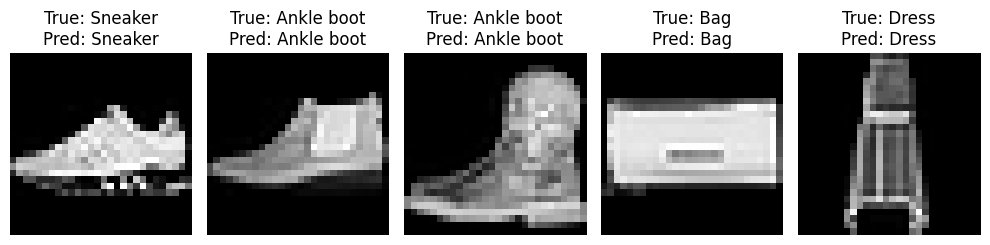

In [29]:
import random

# Show 5 test images with predicted and true labels
plt.figure(figsize=(10, 5))
for i in range(5):
    idx = random.randint(0, len(test_data) - 1)
    image, label = test_data[idx]
    image_input = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_input)
        pred = torch.argmax(output, dim=1).item()

    plt.subplot(1, 5, i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"True: {class_labels[label]}\nPred: {class_labels[pred]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


# 8. Save Model

In [30]:
torch.save(model.state_dict(), 'fashion_cnn_model.pth')
print("Model saved as fashion_cnn_model.pth")


Model saved as fashion_cnn_model.pth
